In [5]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical


(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()


x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


x_train_full = x_train_full.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

In [6]:
from sklearn.model_selection import train_test_split


x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nBaseline Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Baseline Test Accuracy: {test_acc:.4f}")

Training samples: 48000
Validation samples: 12000
Testing samples: 10000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8182 - loss: 0.5152 - val_accuracy: 0.8528 - val_loss: 0.4006
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8625 - loss: 0.3815 - val_accuracy: 0.8595 - val_loss: 0.3808
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8744 - loss: 0.3428 - val_accuracy: 0.8721 - val_loss: 0.3420
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8829 - loss: 0.3192 - val_accuracy: 0.8805 - val_loss: 0.3303
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8890 - loss: 0.3011 - val_accuracy: 0.8801 - val_loss: 0.3223
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8936 - loss: 0.2848 - val_accuracy: 0.8867 - val_loss: 0.3140
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8983 - loss: 0.2717 - val_accuracy: 0.8904 - val_loss: 0.3049
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9024 - loss: 0.2593 - 

In [7]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


model_improved = Sequential([

    Flatten(input_shape=(28, 28, 1)),


    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),


    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),


    Dense(10, activation='softmax')
])

model_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history_improved = model_improved.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.6241 - loss: 1.2878 - val_accuracy: 0.7222 - val_loss: 0.9298
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.6868 - loss: 1.0270 - val_accuracy: 0.7493 - val_loss: 0.8108
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6998 - loss: 0.9477 - val_accuracy: 0.7738 - val_loss: 0.7266
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7073 - loss: 0.9056 - val_accuracy: 0.7778 - val_loss: 0.7096
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7120 - loss: 0.8740 - val_accuracy: 0.7595 - val_loss: 0.7027
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7101 - loss: 0.8685 - val_accuracy: 0.7603 - val_loss: 0.6948
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7093 - loss: 0.8666 - val_accuracy: 0.7703 - val_loss: 0.7082
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.7124 - loss: 0.8614 - val_accurac

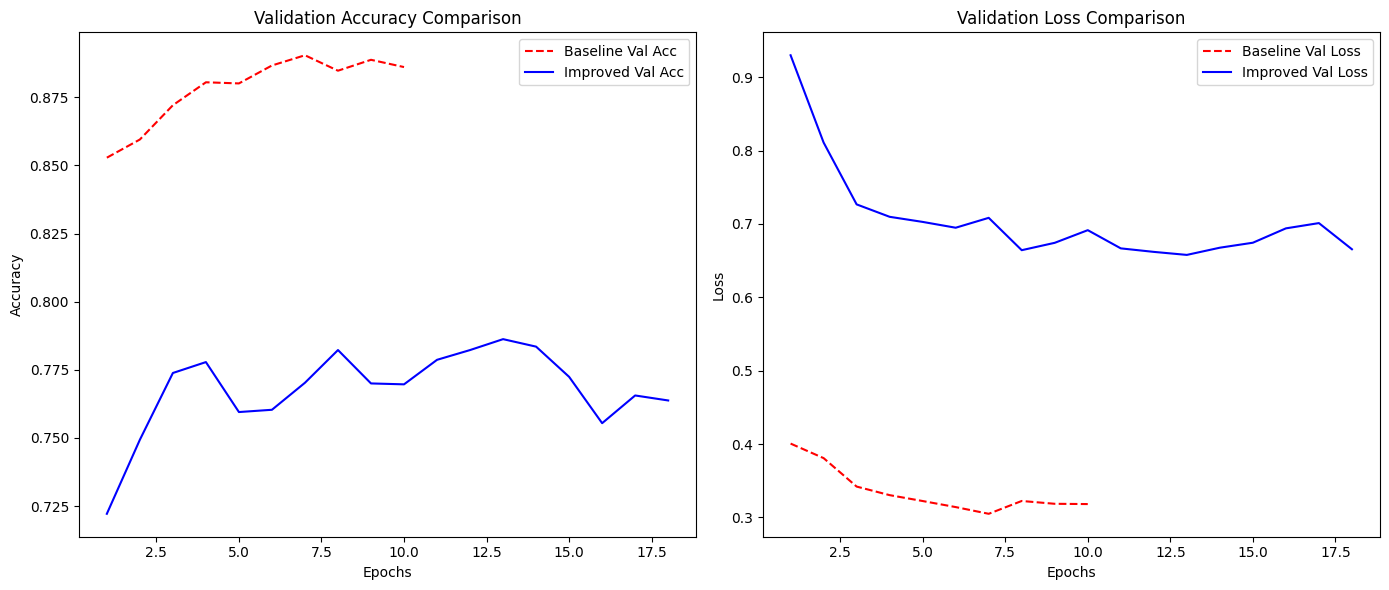

In [8]:
import matplotlib.pyplot as plt

def plot_comparison(history_base, history_imp):
    epochs_base = range(1, len(history_base.history['accuracy']) + 1)
    epochs_imp = range(1, len(history_imp.history['accuracy']) + 1)

    plt.figure(figsize=(14, 6))


    plt.subplot(1, 2, 1)
    plt.plot(epochs_base, history_base.history['val_accuracy'], 'r--', label='Baseline Val Acc')
    plt.plot(epochs_imp, history_imp.history['val_accuracy'], 'b-', label='Improved Val Acc')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(epochs_base, history_base.history['val_loss'], 'r--', label='Baseline Val Loss')
    plt.plot(epochs_imp, history_imp.history['val_loss'], 'b-', label='Improved Val Loss')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_comparison(history, history_improved)